# 07. 아키텍처 비교 — 한방 13-class vs 2계층 (임계값 조정 포함)

기획서의 예상 결과물 1번은 **2단계 계층적 분류**였다.
이 노트북은 그 계획을 **같은 홀드아웃에서 실측으로 반증**하고 한방+사후 임계값조정을 채택한 근거다.

> **출처** — `원본/최종_3차_통합분석.ipynb` (코드 셀 **1개**, 29,946자)
>
> 원본은 `RUN_PART1`~`RUN_PART4` 플래그로 5개 파트를 한 셀에서 켜고 끄는 구조였다.
> 이 저장소는 그 플래그 경계를 그대로 살려 파트별 노트북으로 분리하고,
> **원본 실행 출력(표·그래프)을 해당 셀에 그대로 옮겨 붙였다.**
> 따라서 데이터가 없어도 결과를 볼 수 있고, 데이터가 있으면 그대로 재실행된다.



### 재현 조건

| 항목 | 값 |
|---|---|
| 입력 | `data/X_tr.parquet` · `X_va.parquet` · `y_tr.parquet` · `y_va.parquet` (**3차 전처리**) |
| 형상 | train `(96,140 × 58)` / valid `(23,860 × 58)` |
| 정상 클래스 | `12` (= `m`) |
| 모델 | `LGBMClassifier` · `n_estimators=300` · `class_weight="balanced"` · `random_state=42` |
| 학습 시간 | 약 13초 (4스레드) |

> `data/` 는 용량(141MB) 때문에 저장소에 포함하지 않았다 — `data/README.md` 참고.
> 아래 셀의 출력은 **원본 실행 결과 그대로**다.

> ⚠️ 원본의 `if RUN_PARTn:` 가드는 제거하고 들여쓰기를 풀었다.
> 파트별 노트북이므로 그 파트는 항상 실행된다 — **로직은 원본과 동일**하다.


## 0. 공통 설정 · 데이터 로드 · 모델 학습

다섯 개 노트북이 모두 이 블록으로 시작한다. 원본 통합 셀의 `[0]` 구획이다.


In [ ]:
# [0] 설정 · 데이터 로드 · 모델 학습 (여기부터 순서대로 실행)
import warnings, time, logging
from pathlib import Path
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# ===== 설정 =====
DATA_DIR = "../../data"        # 3차 전처리 parquet 폴더 (원본 실행 경로:
                               #   /mnt/c/Users/dkstj/Desktop/test_uv/3차 전처리 파일)
SEED = 42
LGBM_THREADS = 4
N_ESTIMATORS = 300             # 느리면 150~200 (수치가 달라짐)

RUN_PART1 = True               # 산출물 4종
RUN_COMPARE = True             # 모델 비교(한방 기본/임계값 · 2계층 기본/임계값) — 2계층 학습 포함
RUN_PART2 = True               # 비용기반 임계값
RUN_PART3 = True               # 규칙기반 + ML 결합
RUN_PART4 = True               # 생성 AI 합성데이터 증강 비교 (느림: sdv 필요)

LEAK_COLS = ["is_fraud", "fraud_type", "label", "y"]      # 정답 라벨 자동 제거
LOOKAHEAD_SUSPECT = ["Account_one_month_max_amount", "Account_one_month_std_dev",
                     "Account_dawn_one_month_max_amount", "Account_dawn_one_month_std_dev",
                     "Amount_vs_monthly_max_ratio"]        # 남아 있으면 경고만

# 비용 가정 (팀 합의값으로 교체)
FN_COST = 17_000_000
FP_SCENARIOS = {"A (FP 5k)": 5_000, "B (FP 10k)": 10_000, "C (FP 50k)": 50_000}
MACRO_MIN = 0.60               # 최종 채택 조건: Macro-F1 최소기준선
AMOUNT_COL = "Transaction_Amount_abs"

# 임계값 격자
THR_FULL = [0.9, 0.7, 0.5, 0.3, 0.2, 0.1, 0.05, 0.03, 0.02, 0.01,
            0.005, 0.003, 0.002, 0.001, 0.0005, 0.0002, 0.0]
THR_BARS = [0.0, 0.0002, 0.0005, 0.001, 0.002, 0.003, 0.005, 0.008, 0.01, 0.02, 0.03]
THR_COLLAPSE = [0.0, 0.00001, 0.00002, 0.00005, 0.0001, 0.00015, 0.0002]

SHAP_SAMPLE = 2000
TOP_FEATURES = 15

# [3] 하이브리드
RULE_MIN_SUPPORT = 15
PRECISION_SCAN = [0.85, 0.70, 0.50, 0.30]
CONT_Q_HI, CONT_Q_LO = [0.90, 0.95, 0.99], [0.01, 0.05, 0.10]
VERIFIED_COMPOSITES = ["large_deposit_and_remote_control", "unused_terminal_and_internet",
                       "limit_check_then_transfer", "suspended_recipient_and_withdrawal",
                       "new_recipient_and_large_amount", "weak_signal_composite_score"]
BOOST_WEIGHT = 0.30

# [4] 증강
TRAIN_SUBSAMPLE_NORMAL = 20000
TARGET_PER_CLASS = 500
GEN_EPOCHS = 300

LGBM_PARAMS = dict(n_estimators=N_ESTIMATORS, learning_rate=0.05, num_leaves=31,
                   subsample=0.9, colsample_bytree=0.9, class_weight="balanced",
                   random_state=SEED, n_jobs=LGBM_THREADS, verbose=-1)
lab = lambda i: chr(ord("a") + int(i))
np.random.seed(SEED)

In [ ]:
# ===== 표시 유틸 =====
def _setup_plt():
    import matplotlib
    try:
        ip = get_ipython()  # type: ignore
        if ip is not None:
            ip.run_line_magic("matplotlib", "inline")
    except Exception:
        pass
    import matplotlib.pyplot as plt
    logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
    matplotlib.rcParams["font.family"] = ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]
    matplotlib.rcParams["axes.unicode_minus"] = False
    return plt


def _table(df, caption=""):
    """VS Code/Jupyter면 표로 렌더링(출력 잘림 방지), 아니면 텍스트."""
    if caption:
        print(f"\n[{caption}]")
    try:
        ip = get_ipython()  # type: ignore
        if ip is not None:
            from IPython.display import display
            display(df); return
    except Exception:
        pass
    print(df.to_string(index=False))


def _head(title):
    print("\n" + "=" * 74); print(f" {title}"); print("=" * 74)

In [ ]:
# ===== 데이터 로드 =====
from lightgbm import LGBMClassifier
from sklearn.metrics import (f1_score, accuracy_score, classification_report,
                             confusion_matrix, precision_recall_fscore_support)

_d = Path(DATA_DIR)
X_tr = pd.read_parquet(_d / "X_tr.parquet").reset_index(drop=True)
X_va = pd.read_parquet(_d / "X_va.parquet").reset_index(drop=True)
y_tr = pd.read_parquet(_d / "y_tr.parquet").iloc[:, 0].astype(int).reset_index(drop=True)
y_va = pd.read_parquet(_d / "y_va.parquet").iloc[:, 0].astype(int).reset_index(drop=True)

_drop = [c for c in X_tr.columns if c.lower() in [s.lower() for s in LEAK_COLS]]
if _drop:
    print(f"[누수 제거] 정답 라벨 {_drop} 자동 제외")
    X_tr = X_tr.drop(columns=_drop); X_va = X_va.drop(columns=_drop)
_rest = [c for c in LOOKAHEAD_SUSPECT if c in X_tr.columns]
if _rest:
    print(f"[경고] look-ahead 의심 피처 잔존: {_rest}")
    print("       → as-of(시점까지 누적) 재설계 여부 전처리팀 확인 필요")

normal_idx = int(y_tr.value_counts().idxmax())
classes = sorted(y_tr.unique()); labels = [lab(c) for c in classes]
fcols = list(X_tr.columns)
amount = X_va[AMOUNT_COL].values.copy() if AMOUNT_COL in X_va.columns else None
basis = f"{X_tr.shape[1]} features | valid {len(y_va):,} rows (hold-out)"
basis_kr = f"피처 {X_tr.shape[1]}개 · valid 홀드아웃 {len(y_va):,}행 · 트리 {N_ESTIMATORS}"

_head(f"3차 전처리 통합 분석 — {basis_kr}")
print(f"[데이터] train {X_tr.shape} / valid {X_va.shape} | 정상={normal_idx}({lab(normal_idx)})")


# ===== 모델 학습 (1회, 전 파트 공유) =====
print("\n[학습] LightGBM 13-class ...")
_t = time.time()
model = LGBMClassifier(**LGBM_PARAMS).fit(X_tr, y_tr)
pred = model.predict(X_va)
macro = f1_score(y_va, pred, average="macro")
print(f"[검증] {round(time.time()-_t,1)}s | Macro-F1={macro:.4f} | "
      f"Weighted-F1={f1_score(y_va, pred, average='weighted'):.4f} | "
      f"Accuracy={accuracy_score(y_va, pred):.4f}")
print("  ※ Accuracy는 정상 99%라 무의미 → Macro-F1로 판단")

rep = classification_report(y_va, pred, labels=classes, target_names=labels,
                            output_dict=True, zero_division=0)
proba = model.predict_proba(X_va)
_cls = list(model.classes_); _npos = _cls.index(normal_idx)
risk = 1.0 - proba[:, _npos]                       # 위험점수 = 1 − P(정상)
_fp = proba.copy(); _fp[:, _npos] = -1.0
best_fraud = np.asarray(_cls)[_fp.argmax(axis=1)]  # 정상 제외 최고확률 유형
y_arr = np.asarray(y_va); yb = (y_arr != normal_idx)

[경고] look-ahead 의심 피처 잔존: ['Account_one_month_max_amount', 'Account_one_month_std_dev', 'Account_dawn_one_month_max_amount', 'Account_dawn_one_month_std_dev', 'Amount_vs_monthly_max_ratio']
       → as-of(시점까지 누적) 재설계 여부 전처리팀 확인 필요

 3차 전처리 통합 분석 — 피처 58개 · valid 홀드아웃 23,860행 · 트리 300
[데이터] train (96140, 58) / valid (23860, 58) | 정상=12(m)

[학습] LightGBM 13-class ...
[검증] 13.3s | Macro-F1=0.6138 | Weighted-F1=0.9942 | Accuracy=0.9949
  ※ Accuracy는 정상 99%라 무의미 → Macro-F1로 판단


위험점수 `risk = 1 − P(정상 m)` 기준 임계값 판정 헬퍼. 임계값을 쓰는 파트에서 공통으로 사용한다.


In [ ]:
def thr_predict(thr):
    """위험점수 ≥ thr → 사기(최고확률 유형), 아니면 정상."""
    p = np.full(len(y_arr), normal_idx); m = risk >= thr
    p[m] = best_fraud[m]; return p, m


def thr_scan(grid):
    rows = []
    for t in grid:
        p, m = thr_predict(t)
        fn = int((yb & ~m).sum()); fp = int((~yb & m).sum())
        r = dict(thr=t, macro=round(f1_score(y_arr, p, average="macro"), 4), FN=fn, FP=fp)
        for k, v in FP_SCENARIOS.items():
            r[k] = round((fn * FN_COST + fp * v) / 1e8, 3)
        if amount is not None:
            r["FN실제금액(억)"] = round(float(amount[yb & ~m].sum()) / 1e8, 2)
            r["FN고정값(억)"] = round(fn * FN_COST / 1e8, 2)
        rows.append(r)
    return pd.DataFrame(rows)

## 1-B. 네 가지 조합을 같은 valid 로 비교

| 조합 | 방식 |
|---|---|
| 한방 (기본) | 13클래스 `argmax` — 임계값 개념 없음 |
| 한방 + 임계값 | `risk = 1 − P(m)` 사후 조정 |
| 2계층 (기본) | stage1 이진(0.5) → stage2 유형 |
| 2계층 + 임계값 | stage1 임계값 탐색 |

**2계층의 구조적 약점**: stage1 에서 정상으로 걸러진 건은 stage2 가 볼 기회조차 없다 — 1단계 FN 이 **영구 미탐**으로 굳는 오류 전파.



 [1-B] 모델 비교 — 한방 vs 2계층 (임계값 조정 포함)
[2계층] stage1(정상 vs 사기) + stage2(사기유형) 학습 ...
  학습 완료 2.7s

[모델별 Macro-F1 비교 (동일 valid 홀드아웃)]


,모델,임계값,Macro-F1,미탐(FN),오탐(FP)
0,한방 13-class (기본 argmax),-,0.6138,59,1
1,한방 + 임계값 조정,0.03,0.6395,37,17
2,2계층 TwoStage (기본 0.5),0.5,0.6105,43,51
3,2계층 + 임계값 조정,0.5,0.6105,43,51


  → 최고: 한방 + 임계값 조정 (임계값 0.03) · Macro-F1 0.6395


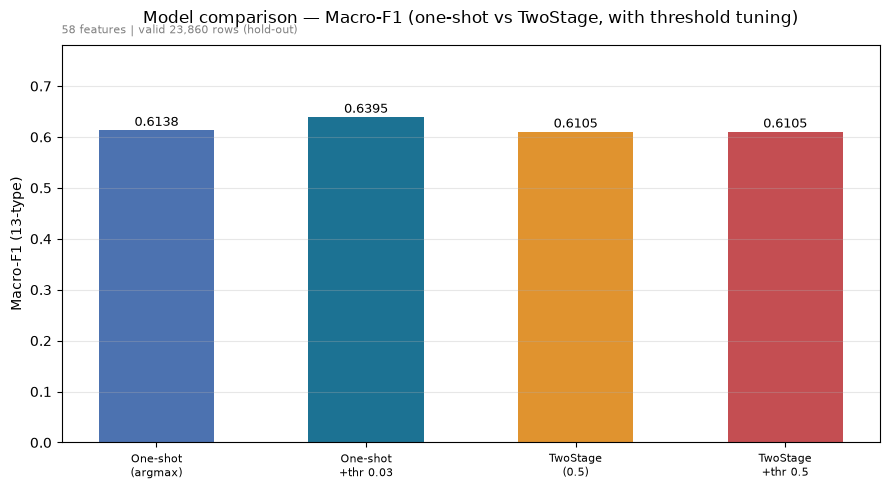

In [ ]:
cmp_tbl = None
_head("[1-B] 모델 비교 — 한방 vs 2계층 (임계값 조정 포함)")
plt = _setup_plt()
rows = []

# ① 한방 기본(argmax)
rows.append({"모델": "한방 13-class (기본 argmax)", "임계값": "-", "Macro-F1": round(macro, 4),
             "미탐(FN)": int((yb & (pred == normal_idx)).sum()),
             "오탐(FP)": int(((~yb) & (pred != normal_idx)).sum())})

# ② 한방 + 임계값 조정 (최고점 자동 탐색)
_sc1 = thr_scan(THR_FULL); _b1 = _sc1.loc[_sc1["macro"].idxmax()]
rows.append({"모델": "한방 + 임계값 조정", "임계값": f"{_b1['thr']:g}", "Macro-F1": _b1["macro"],
             "미탐(FN)": int(_b1["FN"]), "오탐(FP)": int(_b1["FP"])})

# ③④ 2계층(TwoStage) 학습 → 기본(0.5) / 임계값 조정
print("[2계층] stage1(정상 vs 사기) + stage2(사기유형) 학습 ...")
_t2 = time.time()
_ytr = np.asarray(y_tr)
s1 = LGBMClassifier(**LGBM_PARAMS).fit(X_tr, (_ytr != normal_idx).astype(int))
_frm = _ytr != normal_idx
s2 = LGBMClassifier(**LGBM_PARAMS).fit(X_tr[_frm], _ytr[_frm])
risk2 = s1.predict_proba(X_va)[:, 1]
print(f"  학습 완료 {round(time.time()-_t2,1)}s")

def two_pred(t):
    p = np.full(len(y_arr), normal_idx); m = risk2 >= t
    if m.any():
        p[m] = s2.predict(X_va[m])
    return p, m

p2, m2 = two_pred(0.5)
rows.append({"모델": "2계층 TwoStage (기본 0.5)", "임계값": "0.5",
             "Macro-F1": round(f1_score(y_arr, p2, average="macro"), 4),
             "미탐(FN)": int((yb & ~m2).sum()), "오탐(FP)": int(((~yb) & m2).sum())})

_best2 = (0.0, None, 0, 0)
for t in THR_FULL:
    p_, m_ = two_pred(t)
    mac2 = f1_score(y_arr, p_, average="macro")
    if mac2 > _best2[0]:
        _best2 = (mac2, t, int((yb & ~m_).sum()), int(((~yb) & m_).sum()))
rows.append({"모델": "2계층 + 임계값 조정", "임계값": f"{_best2[1]:g}",
             "Macro-F1": round(_best2[0], 4),
             "미탐(FN)": _best2[2], "오탐(FP)": _best2[3]})

cmp_tbl = pd.DataFrame(rows)
_table(cmp_tbl, "모델별 Macro-F1 비교 (동일 valid 홀드아웃)")
_bp = cmp_tbl.loc[cmp_tbl["Macro-F1"].idxmax()]
print(f"  → 최고: {_bp['모델']} (임계값 {_bp['임계값']}) · Macro-F1 {_bp['Macro-F1']}")

fig, ax = plt.subplots(figsize=(9, 5))
b = ax.bar(range(len(cmp_tbl)), cmp_tbl["Macro-F1"], 0.55,
           color=["#4C72B0", "#1C7293", "#E0932F", "#C44E52"])
for r, v in zip(b, cmp_tbl["Macro-F1"]):
    ax.text(r.get_x() + r.get_width()/2, r.get_height() + 0.008, f"{v:.4f}",
            ha="center", fontsize=9)
ax.set_xticks(range(len(cmp_tbl)))
ax.set_xticklabels(["One-shot\n(argmax)", f"One-shot\n+thr {_b1['thr']:g}",
                    "TwoStage\n(0.5)", f"TwoStage\n+thr {_best2[1]:g}"], fontsize=8)
ax.set_ylim(0, max(cmp_tbl["Macro-F1"]) * 1.22); ax.set_ylabel("Macro-F1 (13-type)")
ax.set_title("Model comparison — Macro-F1 (one-shot vs TwoStage, with threshold tuning)", pad=16)
ax.text(0, 1.03, basis, transform=ax.transAxes, fontsize=8, color="gray")
ax.grid(axis="y", alpha=.3); fig.tight_layout(); plt.show()

### 결론

| 모델 | 임계값 | Macro-F1 | 미탐 | 오탐 |
|---|---|---|---|---|
| 한방 13-class (argmax) | — | 0.6138 | 59 | 1 |
| **한방 + 임계값 조정** | **0.03** | **0.6395** | 37 | 17 |
| 2계층 TwoStage | 0.5 | 0.6105 | 43 | 51 |
| 2계층 + 임계값 조정 | 0.5 | 0.6105 | 43 | 51 |

2계층은 임계값을 어떻게 움직여도 **한방 기본보다도 낮다.**
2계층 + 임계값 조정의 최적점이 기본값 0.5 와 같다는 것은, stage1 확률 분포에서
성능을 끌어올릴 여지가 없다는 뜻이다.

→ **한방 + 사후 임계값조정 채택.** 오류 전파가 없으면서 임계값 유연성은 그대로 얻는다.
